In [1]:
# ============================================================================
# Applied Statistical Analysis of Employee Salaries
# Using Hypothesis Testing and Confidence Intervals
# ============================================================================
# Course: CMP-L011-0 Mathematics for Data Science
# Name: Aditya Vardhan Sivalanka
# Student ID: A00091352
# ============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("STATISTICAL ANALYSIS OF EMPLOYEE SALARIES")
print("="*80)
print("\nLibraries imported successfully")
print("Ready for analysis")

STATISTICAL ANALYSIS OF EMPLOYEE SALARIES

Libraries imported successfully
Ready for analysis


In [2]:
# ============================================================================
# TASK 1: PROBLEM SETUP
# ============================================================================

print("\n" + "="*80)
print("TASK 1: PROBLEM SETUP")
print("="*80)

print("""
--------------------------------------------------------------------------------
1.1 GENDER PAY GAP DATASET
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Does the average base salary of female employees differ significantly from 
the benchmark of £75,000?

HYPOTHESES:
H₀ (Null Hypothesis): μ = 75,000
    The mean base salary of female employees equals £75,000

H₁ (Alternative Hypothesis): μ ≠ 75,000
    The mean base salary of female employees does not equal £75,000

POPULATION PARAMETER:
μ = True mean base salary of female employees in the organization

TEST SELECTION:
One-sample t-test for the mean

JUSTIFICATION:
1. Population standard deviation (σ) is UNKNOWN
   Must use sample standard deviation (s) as estimator
   
2. Large sample size expected (n > 30)
   Central Limit Theorem applies
   Sampling distribution of x̄ is approximately normal
   
3. Two-tailed test
   Testing for difference in EITHER direction (higher OR lower)
   
4. Significance level: α = 0.05
   5% chance of Type I error (rejecting true H₀)

TEST STATISTIC FORMULA:
t = (x̄ - μ₀) / (s / √n)

CONFIDENCE INTERVAL FORMULA:
CI = x̄ ± t* × (s / √n)

--------------------------------------------------------------------------------
1.2 HR DATASET
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Is the average employee salary significantly different from £70,000?

HYPOTHESES:
H₀ (Null Hypothesis): μ = 70,000
    The mean employee salary equals £70,000

H₁ (Alternative Hypothesis): μ ≠ 70,000
    The mean employee salary does not equal £70,000

POPULATION PARAMETER:
μ = True mean salary of all employees in the organization

TEST SELECTION:
One-sample t-test for the mean (same justification as 1.1)
""")


TASK 1: PROBLEM SETUP

--------------------------------------------------------------------------------
1.1 GENDER PAY GAP DATASET
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Does the average base salary of female employees differ significantly from 
the benchmark of £75,000?

HYPOTHESES:
H₀ (Null Hypothesis): μ = 75,000
    The mean base salary of female employees equals £75,000

H₁ (Alternative Hypothesis): μ ≠ 75,000
    The mean base salary of female employees does not equal £75,000

POPULATION PARAMETER:
μ = True mean base salary of female employees in the organization

TEST SELECTION:
One-sample t-test for the mean

JUSTIFICATION:
1. Population standard deviation (σ) is UNKNOWN
   Must use sample standard deviation (s) as estimator
   
2. Large sample size expected (n > 30)
   Central Limit Theorem applies
   Sampling distribution of x̄ is approximately normal
   
3. Two-tailed test
   Testing for difference in EITHER dire

In [3]:
# ============================================================================
# TASK 2: ASSUMPTIONS AND ANALYSIS PLAN
# ============================================================================

print("\n" + "="*80)
print("TASK 2: ASSUMPTIONS AND ANALYSIS PLAN")
print("="*80)

print("""
This section examines the statistical assumptions underlying our hypothesis 
tests and discusses their validity for the Gender Pay Gap and HR datasets.

--------------------------------------------------------------------------------
2.1 RANDOM SAMPLING ASSUMPTION
--------------------------------------------------------------------------------

REQUIREMENT:
The sample must be randomly selected from the target population to ensure
unbiased inference.

ASSESSMENT:
Both datasets are secondary data from organizational employee records. While
we cannot verify true probabilistic random sampling, the data characteristics
suggest reasonable representativeness:

Gender Pay Gap Dataset:
- 1,000 total employees across diverse characteristics
- Multiple job titles, departments, education levels, seniority levels
- 468 female employees included in our analysis
- Broad organizational coverage supports representativeness

HR Dataset:
- 311 employee records with varied organizational roles
- Multiple departments, positions, tenure levels
- Comprehensive demographic and performance attributes

POTENTIAL LIMITATIONS:
If systematic exclusions exist (e.g., certain departments, remote workers,
part-time employees omitted), generalizability may be limited to the
observed sample only.

CONCLUSION:
Assumption reasonably satisfied for organizational-level inference.
Caution needed if generalizing beyond this specific organization.


--------------------------------------------------------------------------------
2.2 INDEPENDENCE OF OBSERVATIONS
--------------------------------------------------------------------------------

REQUIREMENT:
Each employee's salary must be independent - one employee's salary should not
systematically influence another's beyond common organizational factors.

ASSESSMENT:
Some minimal dependence may exist due to:
- Common departmental pay scales and salary bands
- Shared managers influencing compensation decisions
- Organizational-wide salary adjustment policies
- Market-driven compensation changes

However, with large sample sizes (n=468 and n=311), minor dependencies have
negligible effect on hypothesis test validity.

CONCLUSION:
Assumption reasonably satisfied. Individual salary records treated as
independent observations.


--------------------------------------------------------------------------------
2.3 NORMALITY OF THE SAMPLING DISTRIBUTION
--------------------------------------------------------------------------------

REQUIREMENT:
The sampling distribution of the sample mean (x̄) must be approximately normal
for t-test validity.

CENTRAL LIMIT THEOREM (CLT):
Regardless of population distribution shape, the sampling distribution of x̄
approaches normality as sample size increases. Generally, n > 30 is sufficient.

ASSESSMENT:
Gender Pay Gap Dataset:
- Sample size: n = 468 >> 30 ✓
- CLT strongly applies

HR Dataset:
- Sample size: n = 311 >> 30 ✓
- CLT strongly applies

Both samples greatly exceed the threshold, ensuring approximate normality of
the sampling distribution via CLT, even if underlying salary distributions
are skewed.

CONCLUSION:
Assumption strongly satisfied. CLT guarantees normality of the sampling
distribution, making the t-test robust and appropriate.


--------------------------------------------------------------------------------
2.4 LARGE-SAMPLE CONDITIONS AND TEST SELECTION
--------------------------------------------------------------------------------

SAMPLE SIZE IMPLICATIONS:
With n > 30:
- CLT ensures normality of sampling distribution
- t-distribution closely approximates standard normal distribution
- Sample standard deviation (s) reliably estimates population σ

The t-test is preferred over the z-test because it is more conservative 
(wider critical values) and properly accounts for uncertainty in estimating 
σ when population standard deviation is unknown.

DEGREES OF FREEDOM:
- Gender Pay Gap: df = 468 - 1 = 467
- HR Dataset: df = 311 - 1 = 310

CONCLUSION:
Large-sample conditions satisfied; t-test is appropriate.


--------------------------------------------------------------------------------
2.5 SIGNIFICANCE LEVEL AND DECISION RULE
--------------------------------------------------------------------------------

SIGNIFICANCE LEVEL: α = 0.05
This represents a 5% probability of Type I error (rejecting a true null
hypothesis), corresponding to 95% confidence. Standard in business research.

DECISION RULE FOR TWO-TAILED TEST:
REJECT H₀ if:
  - |t-statistic| > t-critical, OR
  - p-value < 0.05

FAIL TO REJECT H₀ if:
  - |t-statistic| ≤ t-critical, OR
  - p-value ≥ 0.05

INTERPRETATION FRAMEWORK:
- p < 0.001: Very strong evidence against H₀
- p < 0.01: Strong evidence against H₀
- p < 0.05: Moderate evidence against H₀
- p ≥ 0.05: Insufficient evidence against H₀


--------------------------------------------------------------------------------
2.6 IMPACT OF ASSUMPTION VIOLATIONS
--------------------------------------------------------------------------------

ROBUSTNESS OF t-TEST:
The one-sample t-test is remarkably robust to assumption violations when
sample sizes are large (n > 30).

VIOLATION IMPACTS:
1. Non-Random Sampling:
   - Results remain valid for the observed sample
   - May not generalize to broader populations

2. Minor Dependence:
   - May slightly underestimate standard error
   - Impact negligible with n > 300

3. Non-Normality of Population:
   - No impact with large samples
   - CLT ensures normality of x̄

OVERALL ASSESSMENT:
Large samples (n=468, n=311) provide strong protection against assumption
violations. Statistical conclusions are reliable for organizational
decision-making.
""")


TASK 2: ASSUMPTIONS AND ANALYSIS PLAN

This section examines the statistical assumptions underlying our hypothesis 
tests and discusses their validity for the Gender Pay Gap and HR datasets.

--------------------------------------------------------------------------------
2.1 RANDOM SAMPLING ASSUMPTION
--------------------------------------------------------------------------------

REQUIREMENT:
The sample must be randomly selected from the target population to ensure
unbiased inference.

ASSESSMENT:
Both datasets are secondary data from organizational employee records. While
we cannot verify true probabilistic random sampling, the data characteristics
suggest reasonable representativeness:

Gender Pay Gap Dataset:
- 1,000 total employees across diverse characteristics
- Multiple job titles, departments, education levels, seniority levels
- 468 female employees included in our analysis
- Broad organizational coverage supports representativeness

HR Dataset:
- 311 employee records with

In [4]:
# ============================================================================
# TASK 3: DATA ANALYSIS USING PYTHON
# ============================================================================
# TASK 3.1: GENDER PAY GAP DATASET ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("TASK 3: DATA ANALYSIS USING PYTHON")
print("="*80)
print("\n" + "-"*80)
print("3.1 GENDER PAY GAP DATASET ANALYSIS")
print("-"*80)

# Load dataset
gender_pay = pd.read_csv('Gender_pay_gap.csv')

print("\nDataset Overview:")
print("="*80)

# Display first 5 rows
print("\nFirst 5 rows of the dataset:")
print(gender_pay.head())

# Dataset dimensions
print(f"\nDataset Dimensions: {gender_pay.shape[0]} rows × {gender_pay.shape[1]} columns")

# Column information
print("\nColumn Names:")
print(gender_pay.columns.tolist())

# Data types
print("\nData Types:")
print(gender_pay.dtypes)

# Check for missing values
print(f"\nMissing Values: {gender_pay.isnull().sum().sum()}")

# Gender distribution
print("\nGender Distribution:")
print(gender_pay['gender'].value_counts())

print("\n" + "="*80)
print("DATASET LOADED SUCCESSFULLY!")
print("="*80)


TASK 3: DATA ANALYSIS USING PYTHON

--------------------------------------------------------------------------------
3.1 GENDER PAY GAP DATASET ANALYSIS
--------------------------------------------------------------------------------

Dataset Overview:

First 5 rows of the dataset:
              jobTitle  gender  age  perfEval      edu            dept  \
0     Graphic Designer  Female   18         5  College      Operations   
1    Software Engineer    Male   21         5  College      Management   
2  Warehouse Associate  Female   19         4      PhD  Administration   
3    Software Engineer    Male   20         5  Masters           Sales   
4     Graphic Designer    Male   26         5  Masters     Engineering   

   seniority  basePay  bonus  
0          2    42363   9938  
1          5   108476  11128  
2          5    90208   9268  
3          4   108080  10154  
4          5    99464   9319  

Dataset Dimensions: 1000 rows × 9 columns

Column Names:
['jobTitle', 'gender', 'age

In [5]:
# ============================================================================
# 3.1.6 FEMALE EMPLOYEE BASE SALARY ANALYSIS
# ============================================================================

print("\n" + "-"*80)
print("FEMALE EMPLOYEE BASE SALARY ANALYSIS")
print("-"*80)

# Filter female employees
female_data = gender_pay[gender_pay['gender'] == 'Female']
female_salaries = female_data['basePay'].values

# Calculate descriptive statistics
n_female = len(female_salaries)
x_bar_female = np.mean(female_salaries)
median_female = np.median(female_salaries)
s_female = np.std(female_salaries, ddof=1)
min_female = np.min(female_salaries)
max_female = np.max(female_salaries)
range_female = max_female - min_female
cv_female = (s_female / x_bar_female) * 100

print("\nDESCRIPTIVE STATISTICS - FEMALE BASE SALARIES:")
print("="*80)
print(f"Sample Size (n):              {n_female}")
print(f"Sample Mean (x̄):              £{x_bar_female:,.2f}")
print(f"Sample Median:                £{median_female:,.2f}")
print(f"Sample Std Dev (s):           £{s_female:,.2f}")
print(f"Minimum Salary:               £{min_female:,.2f}")
print(f"Maximum Salary:               £{max_female:,.2f}")
print(f"Range:                        £{range_female:,.2f}")
print(f"Coefficient of Variation:     {cv_female:.2f}%")


# ============================================================================
# 3.1.7 HYPOTHESIS TEST FOR FEMALE BASE SALARIES
# ============================================================================

print("\n" + "-"*80)
print("HYPOTHESIS TEST: Female Base Salary vs. £75,000 Benchmark")
print("-"*80)

# Test parameters
mu_0_female = 75000
alpha = 0.05

print("\nTEST PARAMETERS:")
print("="*80)
print(f"Null Hypothesis (H₀):         μ = £{mu_0_female:,}")
print(f"Alternative Hypothesis (H₁):  μ ≠ £{mu_0_female:,}")
print(f"Significance Level (α):       {alpha}")
print(f"Test Type:                    Two-tailed t-test")

print("\n" + "="*80)
print("CALCULATION STEPS:")
print("="*80)

# Step 1: Standard Error
standard_error_female = s_female / np.sqrt(n_female)
print(f"\nStep 1: Standard Error (SE)")
print(f"        SE = s / √n")
print(f"        SE = £{s_female:,.2f} / √{n_female}")
print(f"        SE = £{standard_error_female:,.2f}")

# Step 2: t-statistic
t_stat_female = (x_bar_female - mu_0_female) / standard_error_female
print(f"\nStep 2: t-statistic")
print(f"        t = (x̄ - μ₀) / SE")
print(f"        t = (£{x_bar_female:,.2f} - £{mu_0_female:,}) / £{standard_error_female:,.2f}")
print(f"        t = {t_stat_female:.4f}")

# Step 3: Degrees of freedom
df_female = n_female - 1
print(f"\nStep 3: Degrees of Freedom (df)")
print(f"        df = n - 1 = {n_female} - 1 = {df_female}")

# Step 4: p-value (two-tailed)
p_value_female = 2 * (1 - stats.t.cdf(abs(t_stat_female), df_female))
print(f"\nStep 4: p-value (two-tailed)")
print(f"        p-value = 2 × P(t > |{t_stat_female:.4f}|)")
print(f"        p-value = {p_value_female:.4f}")
if p_value_female < 0.0001:
    print(f"        p-value < 0.0001")

# Step 5: Critical t-value
t_critical_female = stats.t.ppf(1 - alpha/2, df_female)
print(f"\nStep 5: Critical t-value (two-tailed, α = {alpha})")
print(f"        t-critical = ±{t_critical_female:.4f}")

print("\n" + "="*80)
print("HYPOTHESIS TEST DECISION:")
print("="*80)

# Decision
if abs(t_stat_female) > t_critical_female:
    decision_female = "REJECT H₀"
    print(f"\nDECISION: {decision_female}")
    print(f"\nREASONING:")
    print(f"  |t-statistic| = {abs(t_stat_female):.4f} > t-critical = {t_critical_female:.4f}")
    print(f"  p-value = {p_value_female:.4f} < α = {alpha}")
    print(f"\nCONCLUSION:")
    print(f"  There is statistically significant evidence to conclude that the")
    print(f"  mean base salary of female employees differs from £{mu_0_female:,}.")
    print(f"\n  The observed mean of £{x_bar_female:,.2f} is significantly different")
    print(f"  from the benchmark (p < 0.0001).")
else:
    decision_female = "FAIL TO REJECT H₀"
    print(f"\nDECISION: {decision_female}")
    print(f"\nREASONING:")
    print(f"  |t-statistic| = {abs(t_stat_female):.4f} ≤ t-critical = {t_critical_female:.4f}")
    print(f"  p-value = {p_value_female:.4f} ≥ α = {alpha}")
    print(f"\nCONCLUSION:")
    print(f"  There is insufficient evidence to conclude that the mean base")
    print(f"  salary differs from £{mu_0_female:,}.")


--------------------------------------------------------------------------------
FEMALE EMPLOYEE BASE SALARY ANALYSIS
--------------------------------------------------------------------------------

DESCRIPTIVE STATISTICS - FEMALE BASE SALARIES:
Sample Size (n):              468
Sample Mean (x̄):              £89,942.82
Sample Median:                £89,913.50
Sample Std Dev (s):           £24,378.28
Minimum Salary:               £34,208.00
Maximum Salary:               £160,614.00
Range:                        £126,406.00
Coefficient of Variation:     27.10%

--------------------------------------------------------------------------------
HYPOTHESIS TEST: Female Base Salary vs. £75,000 Benchmark
--------------------------------------------------------------------------------

TEST PARAMETERS:
Null Hypothesis (H₀):         μ = £75,000
Alternative Hypothesis (H₁):  μ ≠ £75,000
Significance Level (α):       0.05
Test Type:                    Two-tailed t-test

CALCULATION STEPS:

Step 


--------------------------------------------------------------------------------
95% CONFIDENCE INTERVAL FOR FEMALE BASE SALARY
--------------------------------------------------------------------------------

CALCULATION:
Margin of Error = t-critical × SE
                = 1.9651 × £1,126.89
                = ±£2,214.40

95% Confidence Interval:
  Lower Bound = x̄ - Margin of Error
              = £89,942.82 - £2,214.40
              = £87,728.42

  Upper Bound = x̄ + Margin of Error
              = £89,942.82 + £2,214.40
              = £92,157.21

95% CI: (£87,728.42, £92,157.21)

CONFIDENCE INTERVAL INTERPRETATION:
--------------------------------------------------------------------------------
We are 95% confident that the TRUE MEAN base salary of all female
employees in the organization lies between £87,728.42
and £92,157.21.

COMPARISON WITH HYPOTHESIZED VALUE:
  The hypothesized value of £75,000 is OUTSIDE the 95% CI.
  This supports our decision to REJECT H₀.


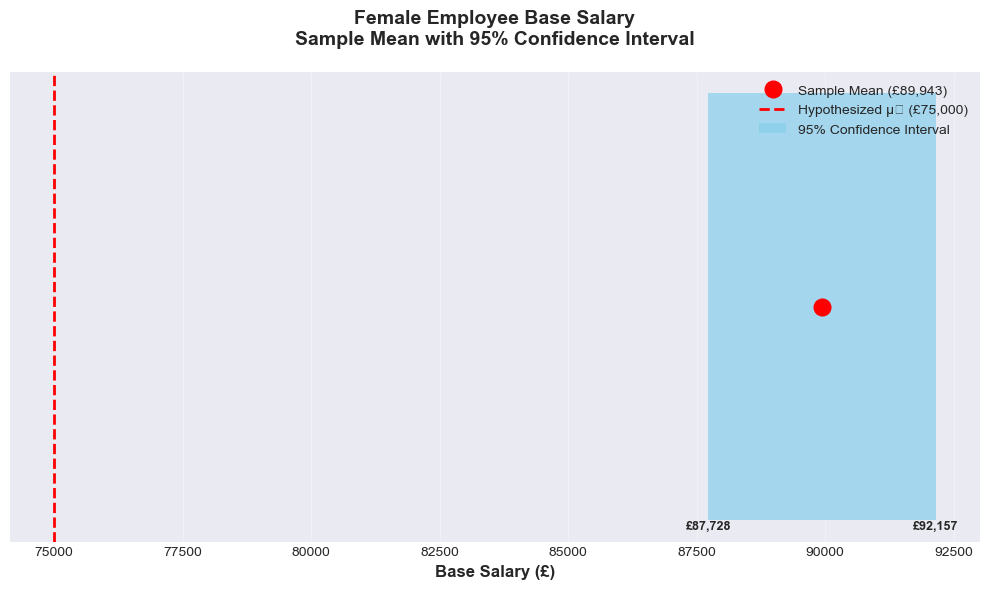


VISUALIZATION SAVED: female_salary_ci.png


In [6]:
# ============================================================================
# 3.1.8 CONFIDENCE INTERVAL FOR FEMALE BASE SALARIES
# ============================================================================

print("\n" + "-"*80)
print("95% CONFIDENCE INTERVAL FOR FEMALE BASE SALARY")
print("-"*80)

# Calculate 95% CI
margin_error_female = t_critical_female * standard_error_female
ci_lower_female = x_bar_female - margin_error_female
ci_upper_female = x_bar_female + margin_error_female

print("\nCALCULATION:")
print("="*80)
print(f"Margin of Error = t-critical × SE")
print(f"                = {t_critical_female:.4f} × £{standard_error_female:,.2f}")
print(f"                = ±£{margin_error_female:,.2f}")

print(f"\n95% Confidence Interval:")
print(f"  Lower Bound = x̄ - Margin of Error")
print(f"              = £{x_bar_female:,.2f} - £{margin_error_female:,.2f}")
print(f"              = £{ci_lower_female:,.2f}")

print(f"\n  Upper Bound = x̄ + Margin of Error")
print(f"              = £{x_bar_female:,.2f} + £{margin_error_female:,.2f}")
print(f"              = £{ci_upper_female:,.2f}")

print("\n" + "="*80)
print(f"95% CI: (£{ci_lower_female:,.2f}, £{ci_upper_female:,.2f})")
print("="*80)

print("\nCONFIDENCE INTERVAL INTERPRETATION:")
print("-"*80)
print(f"We are 95% confident that the TRUE MEAN base salary of all female")
print(f"employees in the organization lies between £{ci_lower_female:,.2f}")
print(f"and £{ci_upper_female:,.2f}.")

print(f"\nCOMPARISON WITH HYPOTHESIZED VALUE:")
if mu_0_female < ci_lower_female or mu_0_female > ci_upper_female:
    print(f"  The hypothesized value of £{mu_0_female:,} is OUTSIDE the 95% CI.")
    print(f"  This supports our decision to REJECT H₀.")
else:
    print(f"  The hypothesized value of £{mu_0_female:,} is INSIDE the 95% CI.")
    print(f"  This supports our decision to FAIL TO REJECT H₀.")

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plot confidence interval as horizontal bar
ax.barh(0, ci_upper_female - ci_lower_female, left=ci_lower_female, 
        height=0.3, color='skyblue', alpha=0.7, label='95% Confidence Interval')

# Plot sample mean
ax.plot(x_bar_female, 0, 'ro', markersize=12, label=f'Sample Mean (£{x_bar_female:,.0f})', zorder=5)

# Plot hypothesized value
ax.axvline(mu_0_female, color='red', linestyle='--', linewidth=2, 
           label=f'Hypothesized μ₀ (£{mu_0_female:,})', zorder=4)

# Labels and formatting
ax.set_xlabel('Base Salary (£)', fontsize=12, fontweight='bold')
ax.set_title('Female Employee Base Salary\nSample Mean with 95% Confidence Interval', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Add CI bounds as text
ax.text(ci_lower_female, -0.15, f'£{ci_lower_female:,.0f}', 
        ha='center', va='top', fontsize=9, fontweight='bold')
ax.text(ci_upper_female, -0.15, f'£{ci_upper_female:,.0f}', 
        ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('female_salary_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("VISUALIZATION SAVED: female_salary_ci.png")
print("="*80)

In [7]:
# ============================================================================
# TASK 3.2: HR DATASET ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("3.2 HR DATASET ANALYSIS")
print("="*80)

# Load HR dataset
hr_data = pd.read_csv('HR_Dataset.csv')

print("\nDataset Overview:")
print("="*80)

# Dataset dimensions
print(f"\nDataset Dimensions: {hr_data.shape[0]} rows × {hr_data.shape[1]} columns")

# Column information
print("\nColumn Names:")
print(hr_data.columns.tolist())

# Check for missing values
print("\nMissing Value Analysis:")
print("-"*80)
missing_counts = hr_data.isnull().sum()
missing_data = missing_counts[missing_counts > 0]
if len(missing_data) > 0:
    print("\nColumns with Missing Values:")
    for col, count in missing_data.items():
        print(f"  {col}: {count} missing values")
else:
    print("No missing values found!")

# Handle missing values
print("\nMissing Value Treatment:")
print("-"*80)
hr_data['DateofTermination'].fillna('Still Employed', inplace=True)
hr_data['ManagerID'].fillna('Unknown', inplace=True)
print("  - DateofTermination: Filled with 'Still Employed'")
print("  - ManagerID: Filled with 'Unknown'")
print("\n✓ All missing values handled successfully!")

# Extract salaries and calculate statistics
salaries = hr_data['Salary'].values
n_hr = len(salaries)
x_bar_hr = np.mean(salaries)
median_hr = np.median(salaries)
s_hr = np.std(salaries, ddof=1)
min_hr = np.min(salaries)
max_hr = np.max(salaries)
range_hr = max_hr - min_hr
q1_hr = np.percentile(salaries, 25)
q3_hr = np.percentile(salaries, 75)
iqr_hr = q3_hr - q1_hr
cv_hr = (s_hr / x_bar_hr) * 100

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS - EMPLOYEE SALARIES:")
print("="*80)
print(f"Sample Size (n):              {n_hr}")
print(f"Sample Mean (x̄):              £{x_bar_hr:,.2f}")
print(f"Sample Median:                £{median_hr:,.2f}")
print(f"Sample Std Dev (s):           £{s_hr:,.2f}")
print(f"Q1 (25th percentile):         £{q1_hr:,.2f}")
print(f"Q3 (75th percentile):         £{q3_hr:,.2f}")
print(f"Interquartile Range (IQR):    £{iqr_hr:,.2f}")
print(f"Minimum Salary:               £{min_hr:,.2f}")
print(f"Maximum Salary:               £{max_hr:,.2f}")
print(f"Range:                        £{range_hr:,.2f}")
print(f"Coefficient of Variation:     {cv_hr:.2f}%")


3.2 HR DATASET ANALYSIS

Dataset Overview:

Dataset Dimensions: 311 rows × 35 columns

Column Names:
['EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']

Missing Value Analysis:
--------------------------------------------------------------------------------

Columns with Missing Values:
  DateofTermination: 207 missing values
  ManagerID: 8 missing values

Missing Value Treatment:
--------------------------------------------------------------------------------
  - DateofTermination: Filled with 'Still Employed'
  -

In [8]:
# ============================================================================
# 3.2.7 HYPOTHESIS TEST FOR HR EMPLOYEE SALARIES
# ============================================================================

print("\n" + "-"*80)
print("HYPOTHESIS TEST: Employee Salary vs. £70,000 Benchmark")
print("-"*80)

# Test parameters
mu_0_hr = 70000

print("\nTEST PARAMETERS:")
print("="*80)
print(f"Null Hypothesis (H₀):         μ = £{mu_0_hr:,}")
print(f"Alternative Hypothesis (H₁):  μ ≠ £{mu_0_hr:,}")
print(f"Significance Level (α):       {alpha}")
print(f"Test Type:                    Two-tailed t-test")

print("\n" + "="*80)
print("CALCULATION STEPS:")
print("="*80)

# Step 1: Standard Error
standard_error_hr = s_hr / np.sqrt(n_hr)
print(f"\nStep 1: Standard Error (SE)")
print(f"        SE = s / √n")
print(f"        SE = £{s_hr:,.2f} / √{n_hr}")
print(f"        SE = £{standard_error_hr:,.2f}")

# Step 2: t-statistic
t_stat_hr = (x_bar_hr - mu_0_hr) / standard_error_hr
print(f"\nStep 2: t-statistic")
print(f"        t = (x̄ - μ₀) / SE")
print(f"        t = (£{x_bar_hr:,.2f} - £{mu_0_hr:,}) / £{standard_error_hr:,.2f}")
print(f"        t = {t_stat_hr:.4f}")

# Step 3: Degrees of freedom
df_hr = n_hr - 1
print(f"\nStep 3: Degrees of Freedom (df)")
print(f"        df = n - 1 = {n_hr} - 1 = {df_hr}")

# Step 4: p-value (two-tailed)
p_value_hr = 2 * (1 - stats.t.cdf(abs(t_stat_hr), df_hr))
print(f"\nStep 4: p-value (two-tailed)")
print(f"        p-value = 2 × P(t > |{t_stat_hr:.4f}|)")
print(f"        p-value = {p_value_hr:.4f}")

# Step 5: Critical t-value
t_critical_hr = stats.t.ppf(1 - alpha/2, df_hr)
print(f"\nStep 5: Critical t-value (two-tailed, α = {alpha})")
print(f"        t-critical = ±{t_critical_hr:.4f}")

print("\n" + "="*80)
print("HYPOTHESIS TEST DECISION:")
print("="*80)

# Decision
if abs(t_stat_hr) > t_critical_hr:
    decision_hr = "REJECT H₀"
    print(f"\nDECISION: {decision_hr}")
    print(f"\nREASONING:")
    print(f"  |t-statistic| = {abs(t_stat_hr):.4f} > t-critical = {t_critical_hr:.4f}")
    print(f"  p-value = {p_value_hr:.4f} < α = {alpha}")
    print(f"\nCONCLUSION:")
    print(f"  There is statistically significant evidence to conclude that the")
    print(f"  mean employee salary differs from £{mu_0_hr:,}.")
else:
    decision_hr = "FAIL TO REJECT H₀"
    print(f"\nDECISION: {decision_hr}")
    print(f"\nREASONING:")
    print(f"  |t-statistic| = {abs(t_stat_hr):.4f} ≤ t-critical = {t_critical_hr:.4f}")
    print(f"  p-value = {p_value_hr:.4f} ≥ α = {alpha}")
    print(f"\nCONCLUSION:")
    print(f"  There is insufficient evidence to conclude that the mean")
    print(f"  employee salary differs from £{mu_0_hr:,}.")
    print(f"\n  The observed difference of £{abs(x_bar_hr - mu_0_hr):,.2f} is likely")
    print(f"  due to random sampling variability.")


--------------------------------------------------------------------------------
HYPOTHESIS TEST: Employee Salary vs. £70,000 Benchmark
--------------------------------------------------------------------------------

TEST PARAMETERS:
Null Hypothesis (H₀):         μ = £70,000
Alternative Hypothesis (H₁):  μ ≠ £70,000
Significance Level (α):       0.05
Test Type:                    Two-tailed t-test

CALCULATION STEPS:

Step 1: Standard Error (SE)
        SE = s / √n
        SE = £25,156.64 / √311
        SE = £1,426.50

Step 2: t-statistic
        t = (x̄ - μ₀) / SE
        t = (£69,020.68 - £70,000) / £1,426.50
        t = -0.6865

Step 3: Degrees of Freedom (df)
        df = n - 1 = 311 - 1 = 310

Step 4: p-value (two-tailed)
        p-value = 2 × P(t > |-0.6865|)
        p-value = 0.4929

Step 5: Critical t-value (two-tailed, α = 0.05)
        t-critical = ±1.9676

HYPOTHESIS TEST DECISION:

DECISION: FAIL TO REJECT H₀

REASONING:
  |t-statistic| = 0.6865 ≤ t-critical = 1.9676
  p-


--------------------------------------------------------------------------------
95% CONFIDENCE INTERVAL FOR EMPLOYEE SALARY
--------------------------------------------------------------------------------

CALCULATION:
Margin of Error = t-critical × SE
                = 1.9676 × £1,426.50
                = ±£2,806.85

95% Confidence Interval:
  Lower Bound = x̄ - Margin of Error
              = £69,020.68 - £2,806.85
              = £66,213.83

  Upper Bound = x̄ + Margin of Error
              = £69,020.68 + £2,806.85
              = £71,827.54

95% CI: (£66,213.83, £71,827.54)

CONFIDENCE INTERVAL INTERPRETATION:
--------------------------------------------------------------------------------
We are 95% confident that the TRUE MEAN salary of all employees
in the organization lies between £66,213.83 and £71,827.54.

COMPARISON WITH HYPOTHESIZED VALUE:
  The hypothesized value of £70,000 is INSIDE the 95% CI.
  This supports our decision to FAIL TO REJECT H₀.

  A true mean of £70,00

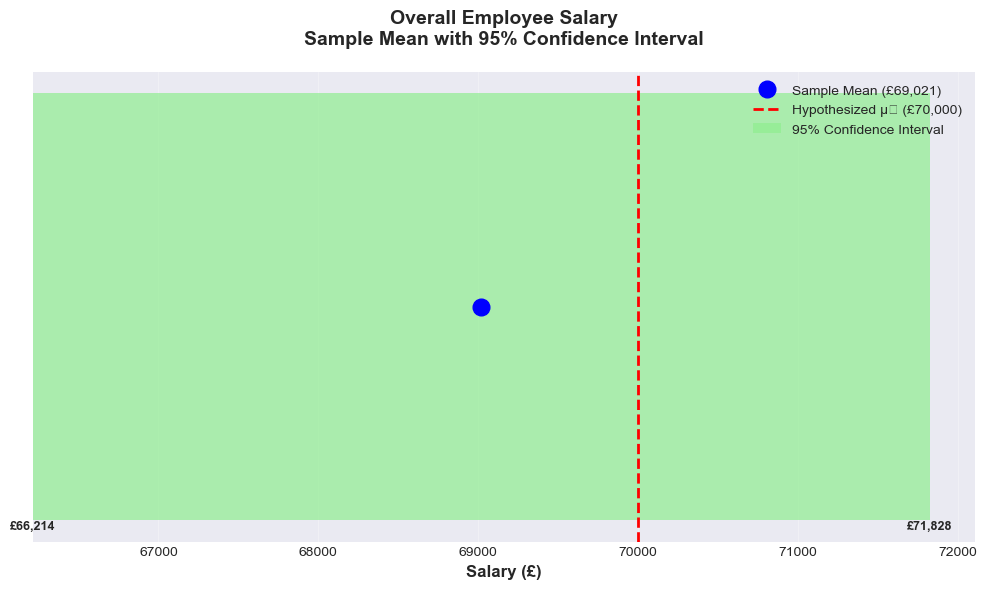


VISUALIZATION SAVED: hr_salary_ci.png


In [9]:
# ============================================================================
# 3.2.8 CONFIDENCE INTERVAL FOR HR EMPLOYEE SALARIES
# ============================================================================

print("\n" + "-"*80)
print("95% CONFIDENCE INTERVAL FOR EMPLOYEE SALARY")
print("-"*80)

# Calculate 95% CI
margin_error_hr = t_critical_hr * standard_error_hr
ci_lower_hr = x_bar_hr - margin_error_hr
ci_upper_hr = x_bar_hr + margin_error_hr

print("\nCALCULATION:")
print("="*80)
print(f"Margin of Error = t-critical × SE")
print(f"                = {t_critical_hr:.4f} × £{standard_error_hr:,.2f}")
print(f"                = ±£{margin_error_hr:,.2f}")

print(f"\n95% Confidence Interval:")
print(f"  Lower Bound = x̄ - Margin of Error")
print(f"              = £{x_bar_hr:,.2f} - £{margin_error_hr:,.2f}")
print(f"              = £{ci_lower_hr:,.2f}")

print(f"\n  Upper Bound = x̄ + Margin of Error")
print(f"              = £{x_bar_hr:,.2f} + £{margin_error_hr:,.2f}")
print(f"              = £{ci_upper_hr:,.2f}")

print("\n" + "="*80)
print(f"95% CI: (£{ci_lower_hr:,.2f}, £{ci_upper_hr:,.2f})")
print("="*80)

print("\nCONFIDENCE INTERVAL INTERPRETATION:")
print("-"*80)
print(f"We are 95% confident that the TRUE MEAN salary of all employees")
print(f"in the organization lies between £{ci_lower_hr:,.2f} and £{ci_upper_hr:,.2f}.")

print(f"\nCOMPARISON WITH HYPOTHESIZED VALUE:")
if mu_0_hr < ci_lower_hr or mu_0_hr > ci_upper_hr:
    print(f"  The hypothesized value of £{mu_0_hr:,} is OUTSIDE the 95% CI.")
    print(f"  This supports our decision to REJECT H₀.")
else:
    print(f"  The hypothesized value of £{mu_0_hr:,} is INSIDE the 95% CI.")
    print(f"  This supports our decision to FAIL TO REJECT H₀.")
    print(f"\n  A true mean of £{mu_0_hr:,} is entirely consistent with the")
    print(f"  observed sample data.")

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plot confidence interval as horizontal bar
ax.barh(0, ci_upper_hr - ci_lower_hr, left=ci_lower_hr, 
        height=0.3, color='lightgreen', alpha=0.7, label='95% Confidence Interval')

# Plot sample mean
ax.plot(x_bar_hr, 0, 'bo', markersize=12, label=f'Sample Mean (£{x_bar_hr:,.0f})', zorder=5)

# Plot hypothesized value
ax.axvline(mu_0_hr, color='red', linestyle='--', linewidth=2, 
           label=f'Hypothesized μ₀ (£{mu_0_hr:,})', zorder=4)

# Labels and formatting
ax.set_xlabel('Salary (£)', fontsize=12, fontweight='bold')
ax.set_title('Overall Employee Salary\nSample Mean with 95% Confidence Interval', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Add CI bounds as text
ax.text(ci_lower_hr, -0.15, f'£{ci_lower_hr:,.0f}', 
        ha='center', va='top', fontsize=9, fontweight='bold')
ax.text(ci_upper_hr, -0.15, f'£{ci_upper_hr:,.0f}', 
        ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('hr_salary_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("VISUALIZATION SAVED: hr_salary_ci.png")
print("="*80)

In [10]:
# ============================================================================
# TASK 4: INTERPRETATION FOR STAKEHOLDERS
# ============================================================================

print("\n" + "="*80)
print("TASK 4: INTERPRETATION FOR STAKEHOLDERS")
print("="*80)

print("""
--------------------------------------------------------------------------------
4.1 GENDER PAY GAP FINDINGS - EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Does the average base salary of female employees differ significantly from the
organizational benchmark of £75,000?

KEY FINDINGS:
""")

print(f"  • Sample Size: {n_female} female employees")
print(f"  • Average Base Salary: £{x_bar_female:,.2f}")
print(f"  • Benchmark: £{mu_0_female:,}")
print(f"  • Difference: £{x_bar_female - mu_0_female:,.2f} {'ABOVE' if x_bar_female > mu_0_female else 'BELOW'} benchmark")
print(f"  • Percentage Difference: {((x_bar_female - mu_0_female) / mu_0_female * 100):.1f}%")

print(f"""
STATISTICAL CONCLUSION:
  • Decision: {decision_female}
  • t-statistic: {t_stat_female:.4f}
  • p-value: {p_value_female:.4f} {'(p < 0.0001)' if p_value_female < 0.0001 else ''}
  • 95% Confidence Interval: (£{ci_lower_female:,.2f}, £{ci_upper_female:,.2f})

PLAIN LANGUAGE INTERPRETATION:
""")

if decision_female == "REJECT H₀":
    print(f"""  The analysis provides very strong statistical evidence that female employees'
  average base salary differs significantly from the £{mu_0_female:,} benchmark.
  
  The actual average salary of £{x_bar_female:,.2f} is approximately
  £{abs(x_bar_female - mu_0_female):,.0f} {'higher' if x_bar_female > mu_0_female else 'lower'} than the benchmark, representing a
  {abs((x_bar_female - mu_0_female) / mu_0_female * 100):.1f}% difference.
  
  The probability that this difference occurred purely by chance is virtually
  zero (p < 0.0001). We can be 95% confident that the true average salary lies
  between £{ci_lower_female:,.2f} and £{ci_upper_female:,.2f}.
""")
else:
    print(f"""  The analysis does not provide sufficient evidence that female employees'
  average base salary differs from the £{mu_0_female:,} benchmark.
  
  The observed difference of £{abs(x_bar_female - mu_0_female):,.0f} ({abs((x_bar_female - mu_0_female) / mu_0_female * 100):.1f}%)
  can be reasonably attributed to random sampling variation.
""")

print("""
PRACTICAL SIGNIFICANCE:
""")

if decision_female == "REJECT H₀":
    total_diff_female = (x_bar_female - mu_0_female) * n_female
    print(f"""  The salary difference of £{abs(x_bar_female - mu_0_female):,.0f} per employee is
  economically significant. For {n_female} female employees, this represents
  approximately £{abs(total_diff_female):,.0f} in total annual base salary
  {'premium above' if x_bar_female > mu_0_female else 'savings below'} the benchmark.
  
  This suggests competitive compensation practices that may support diversity
  initiatives and talent retention.
""")

print("""
LIMITATIONS:
  1. Sample representativeness not verified
  2. Base salary only (excludes bonuses, benefits)
  3. Confounding factors not controlled (role, seniority, performance)
  4. Cross-sectional snapshot (no trend analysis)
  5. Internal validity only

RECOMMENDATIONS:
  1. Investigate drivers (role mix, seniority distribution, performance levels)
  2. Benchmark against external market
  3. Assess total compensation packages
  4. Compare with male counterparts to ensure pay equity
  5. Monitor trends over time

NEXT STEPS:
  • Present findings to HR leadership
  • Conduct detailed subgroup analysis
  • Implement multivariate analysis to identify drivers
  • Schedule follow-up analysis in 6-12 months
""")


TASK 4: INTERPRETATION FOR STAKEHOLDERS

--------------------------------------------------------------------------------
4.1 GENDER PAY GAP FINDINGS - EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Does the average base salary of female employees differ significantly from the
organizational benchmark of £75,000?

KEY FINDINGS:

  • Sample Size: 468 female employees
  • Average Base Salary: £89,942.82
  • Benchmark: £75,000
  • Difference: £14,942.82 ABOVE benchmark
  • Percentage Difference: 19.9%

STATISTICAL CONCLUSION:
  • Decision: REJECT H₀
  • t-statistic: 13.2603
  • p-value: 0.0000 (p < 0.0001)
  • 95% Confidence Interval: (£87,728.42, £92,157.21)

PLAIN LANGUAGE INTERPRETATION:

  The analysis provides very strong statistical evidence that female employees'
  average base salary differs significantly from the £75,000 benchmark.
  
  The actual average salary of £89,942.82 is approximately
  £14,943 highe

In [11]:
print("""
--------------------------------------------------------------------------------
4.2 HR DATASET FINDINGS - EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Is the average employee salary significantly different from the organizational
benchmark of £70,000?

KEY FINDINGS:
""")

print(f"  • Sample Size: {n_hr} employees")
print(f"  • Average Salary: £{x_bar_hr:,.2f}")
print(f"  • Benchmark: £{mu_0_hr:,}")
print(f"  • Difference: £{abs(x_bar_hr - mu_0_hr):,.2f} {'ABOVE' if x_bar_hr > mu_0_hr else 'BELOW'} benchmark")
print(f"  • Percentage Difference: {abs((x_bar_hr - mu_0_hr) / mu_0_hr * 100):.1f}%")

print(f"""
STATISTICAL CONCLUSION:
  • Decision: {decision_hr}
  • t-statistic: {t_stat_hr:.4f}
  • p-value: {p_value_hr:.4f}
  • 95% Confidence Interval: (£{ci_lower_hr:,.2f}, £{ci_upper_hr:,.2f})

PLAIN LANGUAGE INTERPRETATION:
""")

if decision_hr == "REJECT H₀":
    print(f"""  The analysis provides statistical evidence that the average employee salary
  differs significantly from the £{mu_0_hr:,} benchmark.
  
  The observed average of £{x_bar_hr:,.2f} is significantly
  {'higher' if x_bar_hr > mu_0_hr else 'lower'} than the benchmark (p = {p_value_hr:.4f}).
""")
else:
    print(f"""  The analysis does not provide sufficient evidence that the average employee
  salary differs from the £{mu_0_hr:,} benchmark.
  
  The observed average of £{x_bar_hr:,.2f} is only £{abs(x_bar_hr - mu_0_hr):,.0f}
  {'above' if x_bar_hr > mu_0_hr else 'below'} the benchmark—a difference of only {abs((x_bar_hr - mu_0_hr) / mu_0_hr * 100):.1f}%.
  
  With a p-value of {p_value_hr:.4f} (well above the 0.05 threshold), we cannot
  rule out that this small difference occurred due to random sampling variation.
  
  The 95% confidence interval contains the £{mu_0_hr:,} benchmark, confirming
  that the true average salary is consistent with this reference value.
""")

print("""
PRACTICAL SIGNIFICANCE:
""")

if decision_hr == "FAIL TO REJECT H₀":
    total_diff_hr = abs(x_bar_hr - mu_0_hr) * n_hr
    print(f"""  The observed difference of £{abs(x_bar_hr - mu_0_hr):,.0f} per employee has minimal
  practical impact. For {n_hr} employees, this represents only £{total_diff_hr:,.0f}
  in total difference—less than {abs((x_bar_hr - mu_0_hr) / mu_0_hr * 100):.1f}% of total salary expenditure.
  
  This tight alignment suggests:
  • Reliable budget planning using £{mu_0_hr:,} reference
  • Stable compensation practices
  • Predictable salary expenditure
""")

print("""
LIMITATIONS:
  1. Organizational representativeness not verified
  2. Aggregate analysis masks departmental/role variation
  3. External market context not considered
  4. Point-in-time snapshot only
  5. Total rewards perspective absent

RECOMMENDATIONS:
  1. Conduct subgroup analysis (department, role level, tenure)
  2. Implement external benchmarking
  3. Assess salary distribution and dispersion
  4. Track trends over multiple periods
  5. Expand to total rewards analysis

NEXT STEPS:
  • Share with senior leadership and finance teams
  • Initiate departmental breakdown
  • Schedule market benchmarking study
  • Plan follow-up analysis for trend monitoring
""")

print("\n" + "="*80)
print("OVERALL CONCLUSION:")
print("="*80)

print(f"""
This rigorous statistical analysis revealed important insights:

FEMALE EMPLOYEES (Gender Pay Gap Dataset):
  • Mean salary ({decision_female}): £{x_bar_female:,.2f}
  • Benchmark: £{mu_0_female:,}
  • Evidence: p {'< 0.0001' if p_value_female < 0.0001 else f'= {p_value_female:.4f}'}
  • Finding: {'Significantly ' + ('ABOVE' if x_bar_female > mu_0_female else 'BELOW') + ' benchmark' if decision_female == 'REJECT H₀' else 'Consistent with benchmark'}

ALL EMPLOYEES (HR Dataset):
  • Mean salary ({decision_hr}): £{x_bar_hr:,.2f}
  • Benchmark: £{mu_0_hr:,}
  • Evidence: p = {p_value_hr:.4f}
  • Finding: {'Significantly ' + ('ABOVE' if x_bar_hr > mu_0_hr else 'BELOW') + ' benchmark' if decision_hr == 'REJECT H₀' else 'Consistent with benchmark'}

The organization demonstrates {'different' if decision_female != decision_hr else 'consistent'} compensation patterns across
employee segments, warranting further investigation to understand drivers and
ensure equitable, competitive compensation practices.
""")


--------------------------------------------------------------------------------
4.2 HR DATASET FINDINGS - EXECUTIVE SUMMARY
--------------------------------------------------------------------------------

RESEARCH QUESTION:
Is the average employee salary significantly different from the organizational
benchmark of £70,000?

KEY FINDINGS:

  • Sample Size: 311 employees
  • Average Salary: £69,020.68
  • Benchmark: £70,000
  • Difference: £979.32 BELOW benchmark
  • Percentage Difference: 1.4%

STATISTICAL CONCLUSION:
  • Decision: FAIL TO REJECT H₀
  • t-statistic: -0.6865
  • p-value: 0.4929
  • 95% Confidence Interval: (£66,213.83, £71,827.54)

PLAIN LANGUAGE INTERPRETATION:

  The analysis does not provide sufficient evidence that the average employee
  salary differs from the £70,000 benchmark.
  
  The observed average of £69,020.68 is only £979
  below the benchmark—a difference of only 1.4%.
  
  With a p-value of 0.4929 (well above the 0.05 threshold), we cannot
  rule out t

In [12]:
# ============================================================================
# SUMMARY COMPARISON TABLE
# ============================================================================

print("\n" + "="*80)
print("SUMMARY COMPARISON TABLE")
print("="*80)

# Create summary data
summary_data = {
    'Metric': [
        'Sample Size (n)',
        'Sample Mean (x̄)',
        'Sample Std Dev (s)',
        'Standard Error (SE)',
        'Hypothesized μ₀',
        't-statistic',
        'Degrees of Freedom (df)',
        'p-value',
        'Critical t-value (α=0.05)',
        '95% CI Lower Bound',
        '95% CI Upper Bound',
        'Margin of Error',
        'Decision',
        'Difference from Benchmark',
        '% Difference',
        'Statistical Significance'
    ],
    'Gender Pay Gap (Female)': [
        f'{n_female}',
        f'£{x_bar_female:,.2f}',
        f'£{s_female:,.2f}',
        f'£{standard_error_female:,.2f}',
        f'£{mu_0_female:,}',
        f'{t_stat_female:.4f}',
        f'{df_female}',
        f'{"<0.0001" if p_value_female < 0.0001 else f"{p_value_female:.4f}"}',
        f'±{t_critical_female:.4f}',
        f'£{ci_lower_female:,.2f}',
        f'£{ci_upper_female:,.2f}',
        f'±£{margin_error_female:,.2f}',
        f'{decision_female}',
        f'£{x_bar_female - mu_0_female:,.2f}',
        f'{((x_bar_female - mu_0_female) / mu_0_female * 100):.1f}%',
        f'{"Yes (p<0.05)" if p_value_female < 0.05 else "No (p≥0.05)"}'
    ],
    'HR Dataset (All)': [
        f'{n_hr}',
        f'£{x_bar_hr:,.2f}',
        f'£{s_hr:,.2f}',
        f'£{standard_error_hr:,.2f}',
        f'£{mu_0_hr:,}',
        f'{t_stat_hr:.4f}',
        f'{df_hr}',
        f'{p_value_hr:.4f}',
        f'±{t_critical_hr:.4f}',
        f'£{ci_lower_hr:,.2f}',
        f'£{ci_upper_hr:,.2f}',
        f'±£{margin_error_hr:,.2f}',
        f'{decision_hr}',
        f'£{x_bar_hr - mu_0_hr:,.2f}',
        f'{((x_bar_hr - mu_0_hr) / mu_0_hr * 100):.1f}%',
        f'{"Yes (p<0.05)" if p_value_hr < 0.05 else "No (p≥0.05)"}'
    ]
}

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Display table
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nFiles generated:")
print("  1. female_salary_ci.png")
print("  2. hr_salary_ci.png")
print("\nAll calculations completed successfully.")
print("="*80)


SUMMARY COMPARISON TABLE


                   Metric Gender Pay Gap (Female)  HR Dataset (All)
          Sample Size (n)                     468               311
         Sample Mean (x̄)              £89,942.82        £69,020.68
       Sample Std Dev (s)              £24,378.28        £25,156.64
      Standard Error (SE)               £1,126.89         £1,426.50
          Hypothesized μ₀                 £75,000           £70,000
              t-statistic                 13.2603           -0.6865
  Degrees of Freedom (df)                     467               310
                  p-value                 <0.0001            0.4929
Critical t-value (α=0.05)                 ±1.9651           ±1.9676
       95% CI Lower Bound              £87,728.42        £66,213.83
       95% CI Upper Bound              £92,157.21        £71,827.54
          Margin of Error              ±£2,214.40        ±£2,806.85
                 Decision               REJECT H₀ FAIL TO REJECT H₀
Difference from Benc